Insira os seguintes dados para a curva de concordância:


Cota do PIV (I):  160
Inclinação inicial i1 (use decimal, ex: 0.025 para 2,5%):  -0.03
Inclinação final i2 (use decimal, ex: -0.010 para -1,0%):  0.02
Comprimento da curva L (m):  160


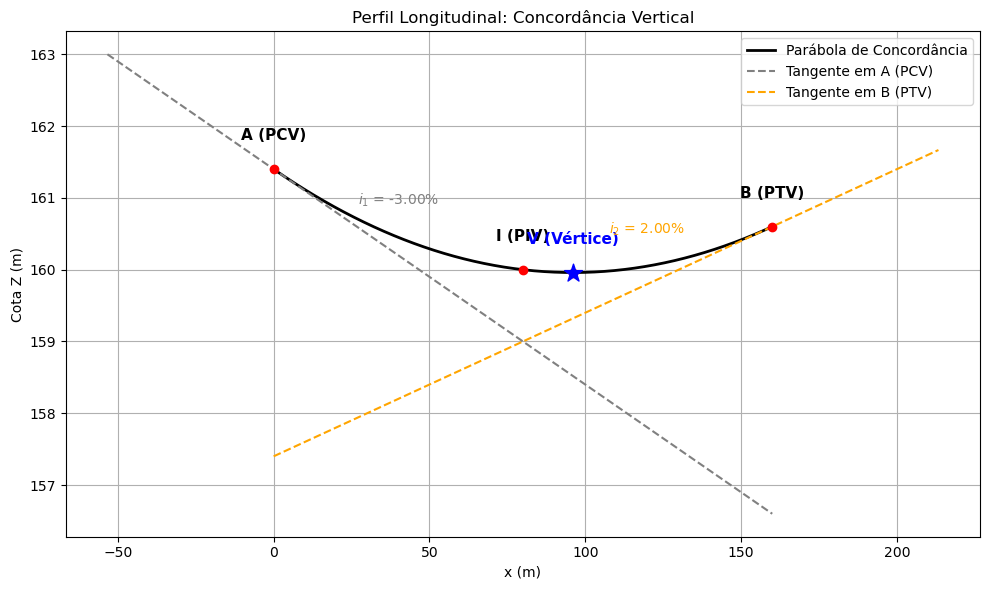


--- Resultados ---
Desnível (g) = i1 - i2 = -0.05000
Flecha vertical (e) = -1.0000 m
Cota de A (PCV): Z_A = 161.400 m
Cota de B (PTV): Z_B = 160.600 m
Cota do PIV na parábola: Z_I = 160.000 m (deve coincidir com a entrada)
Coordenadas do vértice: x_V = 96.000 m, Z_V = 159.960 m


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Solicitar dados ao usuário
print("Insira os seguintes dados para a curva de concordância:")
Z_I = float(input("Cota do PIV (I): "))
i1 = float(input("Inclinação inicial i1 (use decimal, ex: 0.025 para 2,5%): "))
i2 = float(input("Inclinação final i2 (use decimal, ex: -0.010 para -1,0%): "))
L = float(input("Comprimento da curva L (m): "))

# Cálculo do desnível g e da flecha e
g = i1 - i2
e = (L/8)*g

# Cota de A (PCV)
Z_A = Z_I - i1 * (L/2) + e

# Cota de B (PTV)
Z_B = Z_A + ((i1 + i2)/2) * L

# Ponto V (vértice da parábola)
x_V = (i1 * L)/g if g != 0 else np.nan
y_V = (i1**2 * L)/(2 * g) if g != 0 else np.nan
Z_V = Z_A + y_V if g != 0 else np.nan

# Coordenadas dos pontos
x_A, x_B, x_I = 0, L, L/2
Z_I_parab = Z_A + i1 * (L/2) - e  # Cota na parábola no PIV

# Geração da parábola
x_vals = np.linspace(0, L, 200)
y_vals = i1 * x_vals - (g/(2*L)) * x_vals**2
Z_parab = Z_A + y_vals

# Tangentes
x_tanA = np.linspace(-L/3, L, 100)
Z_tanA = Z_A + i1 * x_tanA

x_tanB = np.linspace(0, L+L/3, 100)
Z_tanB = Z_B + i2 * (x_tanB - L)

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(x_vals, Z_parab, 'k', lw=2, label='Parábola de Concordância')
plt.plot(x_tanA, Z_tanA, '--', color='gray', label='Tangente em A (PCV)')
plt.plot(x_tanB, Z_tanB, '--', color='orange', label='Tangente em B (PTV)')

# Pontos notáveis
plt.scatter([x_A, x_B, x_I, x_V], [Z_A, Z_B, Z_I_parab, Z_V], color='red', zorder=5)
plt.scatter([x_V], [Z_V], color='blue', zorder=6, marker='*', s=180)

# Labels dos pontos
plt.text(x_A, Z_A+0.4, "A (PCV)", ha='center', fontsize=11, fontweight='bold')
plt.text(x_B, Z_B+0.4, "B (PTV)", ha='center', fontsize=11, fontweight='bold')
plt.text(x_I, Z_I_parab+0.4, "I (PIV)", ha='center', fontsize=11, fontweight='bold')
plt.text(x_V, Z_V+0.4, "V (Vértice)", ha='center', fontsize=11, color='blue', fontweight='bold')

# Inclinações
plt.text(x_I/2, Z_A + i1*(x_I/2) + 0.7, f"$i_1$ = {i1*100:.2f}%", ha='center', fontsize=10, color='gray')
plt.text((x_I+L)/2, Z_B + i2*((((x_I+L)/2)-L)) + 0.7, f"$i_2$ = {i2*100:.2f}%", ha='center', fontsize=10, color='orange')

plt.xlabel('x (m)')
plt.ylabel('Cota Z (m)')
plt.title('Perfil Longitudinal: Concordância Vertical')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Exibir os valores calculados
print("\n--- Resultados ---")
print(f"Desnível (g) = i1 - i2 = {g:.5f}")
print(f"Flecha vertical (e) = {e:.4f} m")
print(f"Cota de A (PCV): Z_A = {Z_A:.3f} m")
print(f"Cota de B (PTV): Z_B = {Z_B:.3f} m")
print(f"Cota do PIV na parábola: Z_I = {Z_I_parab:.3f} m (deve coincidir com a entrada)")
print(f"Coordenadas do vértice: x_V = {x_V:.3f} m, Z_V = {Z_V:.3f} m")


##### import numpy as np
import matplotlib.pyplot as plt

print("=== Concordância Vertical: Gerador de Perfil Longitudinal ===\n")
tipo = input("Tipo de curva (C para Convexa, N para Côncava): ").strip().upper()
while tipo not in ["C", "N"]:
    tipo = input("Por favor, digite 'C' para Convexa ou 'N' para Côncava: ").strip().upper()

Z_I = float(input("Cota do PIV (I): "))
i1_valor = float(input("Valor de i1 (%): "))
i2_valor = float(input("Valor de i2 (%): "))
L = float(input("Comprimento da curva L (m): "))

# Ajuste dos sinais conforme o tipo de curva
if tipo == "C":
    i1 = i1_valor / 100     # positivo
    i2 = -i2_valor / 100    # negativo
    curva_tipo = "Convexa"
else:
    i1 = -i1_valor / 100    # negativo
    i2 = i2_valor / 100     # positivo
    curva_tipo = "Côncava"

g = i1 - i2
e = (L / 8) * g

# Cotas dos pontos
Z_A = Z_I - i1 * (L/2) + e
Z_B = Z_A + ((i1 + i2)/2) * L

# Vértice da parábola
x_V = (i1 * L) / g if g != 0 else np.nan
y_V = (i1**2 * L) / (2 * g) if g != 0 else np.nan
Z_V = Z_A + y_V if g != 0 else np.nan

# Pontos notáveis
x_A, x_B, x_I = 0, L, L/2
Z_I_parab = Z_A + i1 * (L/2) - e

# Geração da parábola
x_vals = np.linspace(0, L, 200)
y_vals = i1 * x_vals - (g/(2*L)) * x_vals**2
Z_parab = Z_A + y_vals

# Tangentes
x_tanA = np.linspace(-L/3, L, 100)
Z_tanA = Z_A + i1 * x_tanA

x_tanB = np.linspace(0, L+L/3, 100)
Z_tanB = Z_B + i2 * (x_tanB - L)

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(x_vals, Z_parab, 'k', lw=2, label='Parábola de Concordância')
plt.plot(x_tanA, Z_tanA, '--', color='gray', label='Tangente em A (PCV)')
plt.plot(x_tanB, Z_tanB, '--', color='orange', label='Tangente em B (PTV)')

# Pontos notáveis
plt.scatter([x_A, x_B, x_I, x_V], [Z_A, Z_B, Z_I_parab, Z_V], color='red', zorder=5)
plt.scatter([x_V], [Z_V], color='blue', zorder=6, marker='*', s=180)

# Labels dos pontos
plt.text(x_A, Z_A+0.4, "A (PCV)", ha='center', fontsize=11, fontweight='bold')
plt.text(x_B, Z_B+0.4, "B (PTV)", ha='center', fontsize=11, fontweight='bold')
plt.text(x_I, Z_I_parab+0.4, "I (PIV)", ha='center', fontsize=11, fontweight='bold')
plt.text(x_V, Z_V+0.4, "V (Vértice)", ha='center', fontsize=11, color='blue', fontweight='bold')

# Inclinações
plt.text(x_I/2, Z_A + i1*(x_I/2) + 0.7, f"$i_1$ = {i1*100:+.2f}%", ha='center', fontsize=10, color='gray')
plt.text((x_I+L)/2, Z_B + i2*((((x_I+L)/2)-L)) + 0.7, f"$i_2$ = {i2*100:+.2f}%", ha='center', fontsize=10, color='orange')

plt.xlabel('x (m)')
plt.ylabel('Cota Z (m)')
plt.title(f'Perfil Longitudinal: Concordância Vertical ({curva_tipo})')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Exibir os valores calculados
print(f"\n=== Resultados ({curva_tipo}) ===")
print(f"Desnível (g) = i1 - i2 = {g:.5f}")
print(f"Flecha vertical (e) = {e:.4f} m")
print(f"Cota de A (PCV): Z_A = {Z_A:.3f} m")
print(f"Cota de B (PTV): Z_B = {Z_B:.3f} m")
print(f"Cota do PIV na parábola: Z_I = {Z_I_parab:.3f} m (deve coincidir com a entrada)")
print(f"Coordenadas do vértice: x_V = {x_V:.3f} m, Z_V = {Z_V:.3f} m")


=== Concordância Vertical: Gerador de Perfil Longitudinal ===



Tipo de curva (C para Convexa, N para Côncava):  C
Cota do PIV (I):  500
Valor de i1 (%):  3
Valor de i2 (%):  2
Comprimento da curva L (m):  200


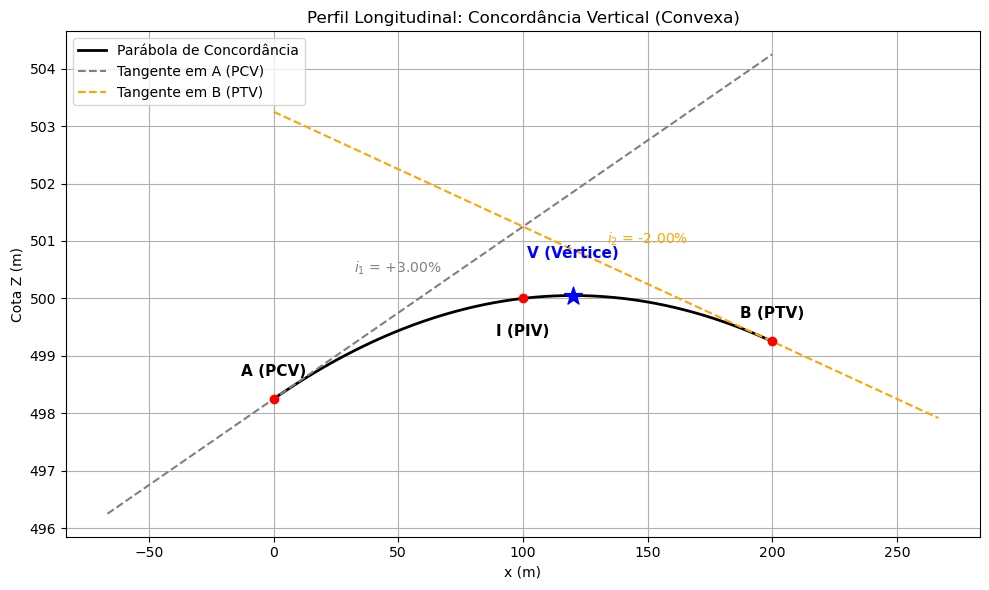


=== Resultados (Convexa) ===
Desnível (g) = i1 - i2 = 0.05000
Flecha vertical (e) = 1.2500 m
Cota de A (PCV): Z_A = 498.250 m
Cota de B (PTV): Z_B = 499.250 m
Cota do PIV na parábola: Z_I = 500.000 m (deve coincidir com a entrada)
Coordenadas do vértice: x_V = 120.000 m, Z_V = 500.050 m


In [5]:
import numpy as np
import matplotlib.pyplot as plt

print("=== Concordância Vertical: Gerador de Perfil Longitudinal ===\n")
tipo = input("Tipo de curva (C para Convexa, N para Côncava): ").strip().upper()
while tipo not in ["C", "N"]:
    tipo = input("Por favor, digite 'C' para Convexa ou 'N' para Côncava: ").strip().upper()

Z_I = float(input("Cota do PIV (I): "))
i1_valor = float(input("Valor de i1 (%): "))
i2_valor = float(input("Valor de i2 (%): "))
L = float(input("Comprimento da curva L (m): "))

# Ajuste dos sinais conforme o tipo de curva
if tipo == "C":
    i1 = i1_valor / 100     # positivo
    i2 = -i2_valor / 100    # negativo
    curva_tipo = "Convexa"
else:
    i1 = -i1_valor / 100    # negativo
    i2 = i2_valor / 100     # positivo
    curva_tipo = "Côncava"

g = i1 - i2
e = (L / 8) * g

# Cotas dos pontos
Z_A = Z_I - i1 * (L/2) + e
Z_B = Z_A + ((i1 + i2)/2) * L

# Vértice da parábola
x_V = (i1 * L) / g if g != 0 else np.nan
y_V = (i1**2 * L) / (2 * g) if g != 0 else np.nan
Z_V = Z_A + y_V if g != 0 else np.nan

# Pontos notáveis
x_A, x_B, x_I = 0, L, L/2
Z_I_parab = Z_A + i1 * (L/2) - e

# Geração da parábola
x_vals = np.linspace(0, L, 200)
y_vals = i1 * x_vals - (g/(2*L)) * x_vals**2
Z_parab = Z_A + y_vals

# Tangentes
x_tanA = np.linspace(-L/3, L, 100)
Z_tanA = Z_A + i1 * x_tanA

x_tanB = np.linspace(0, L+L/3, 100)
Z_tanB = Z_B + i2 * (x_tanB - L)

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(x_vals, Z_parab, 'k', lw=2, label='Parábola de Concordância')
plt.plot(x_tanA, Z_tanA, '--', color='gray', label='Tangente em A (PCV)')
plt.plot(x_tanB, Z_tanB, '--', color='orange', label='Tangente em B (PTV)')

# Pontos notáveis
plt.scatter([x_A, x_B, x_I], [Z_A, Z_B, Z_I_parab], color='red', zorder=5)
plt.scatter([x_V], [Z_V], color='blue', zorder=6, marker='*', s=180)

# Labels dos pontos A e B
plt.text(x_A, Z_A+0.4 if curva_tipo=="Convexa" else Z_A-0.4, "A (PCV)", ha='center', fontsize=11, fontweight='bold')
plt.text(x_B, Z_B+0.4 if curva_tipo=="Convexa" else Z_B-0.4, "B (PTV)", ha='center', fontsize=11, fontweight='bold')

# Posicionamento inteligente dos labels V (Vértice) e I (PIV)
dx = L * 0.03
dy = (abs(Z_V - Z_I_parab) + 0.6) * (1 if curva_tipo == "Convexa" else -1)

if abs(x_V - x_I) < 0.15 * L:
    # Muito próximos: separam na vertical
    if curva_tipo == "Convexa":
        plt.text(x_V, Z_V + abs(dy), "V (Vértice)", ha='center', fontsize=11, color='blue', fontweight='bold')
        plt.text(x_I, Z_I_parab - abs(dy), "I (PIV)", ha='center', fontsize=11, fontweight='bold')
    else:
        plt.text(x_V, Z_V - abs(dy), "V (Vértice)", ha='center', fontsize=11, color='blue', fontweight='bold')
        plt.text(x_I, Z_I_parab + abs(dy), "I (PIV)", ha='center', fontsize=11, fontweight='bold')
else:
    # Afastados: um à esquerda e um à direita, ambos acima ou abaixo
    if curva_tipo == "Convexa":
        plt.text(x_V - dx, Z_V + 0.7, "V (Vértice)", ha='center', fontsize=11, color='blue', fontweight='bold')
        plt.text(x_I + dx, Z_I_parab + 0.7, "I (PIV)", ha='center', fontsize=11, fontweight='bold')
    else:
        plt.text(x_V - dx, Z_V - 0.7, "V (Vértice)", ha='center', fontsize=11, color='blue', fontweight='bold')
        plt.text(x_I + dx, Z_I_parab - 0.7, "I (PIV)", ha='center', fontsize=11, fontweight='bold')

# Inclinações
plt.text(x_I/2, Z_A + i1*(x_I/2) + (0.7 if curva_tipo=="Convexa" else -0.7),
         f"$i_1$ = {i1*100:+.2f}%", ha='center', fontsize=10, color='gray')
plt.text((x_I+L)/2, Z_B + i2*((((x_I+L)/2)-L)) + (0.7 if curva_tipo=="Convexa" else -0.7),
         f"$i_2$ = {i2*100:+.2f}%", ha='center', fontsize=10, color='orange')

plt.xlabel('x (m)')
plt.ylabel('Cota Z (m)')
plt.title(f'Perfil Longitudinal: Concordância Vertical ({curva_tipo})')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Exibir os valores calculados
print(f"\n=== Resultados ({curva_tipo}) ===")
print(f"Desnível (g) = i1 - i2 = {g:.5f}")
print(f"Flecha vertical (e) = {e:.4f} m")
print(f"Cota de A (PCV): Z_A = {Z_A:.3f} m")
print(f"Cota de B (PTV): Z_B = {Z_B:.3f} m")
print(f"Cota do PIV na parábola: Z_I = {Z_I_parab:.3f} m (deve coincidir com a entrada)")
print(f"Coordenadas do vértice: x_V = {x_V:.3f} m, Z_V = {Z_V:.3f} m")
